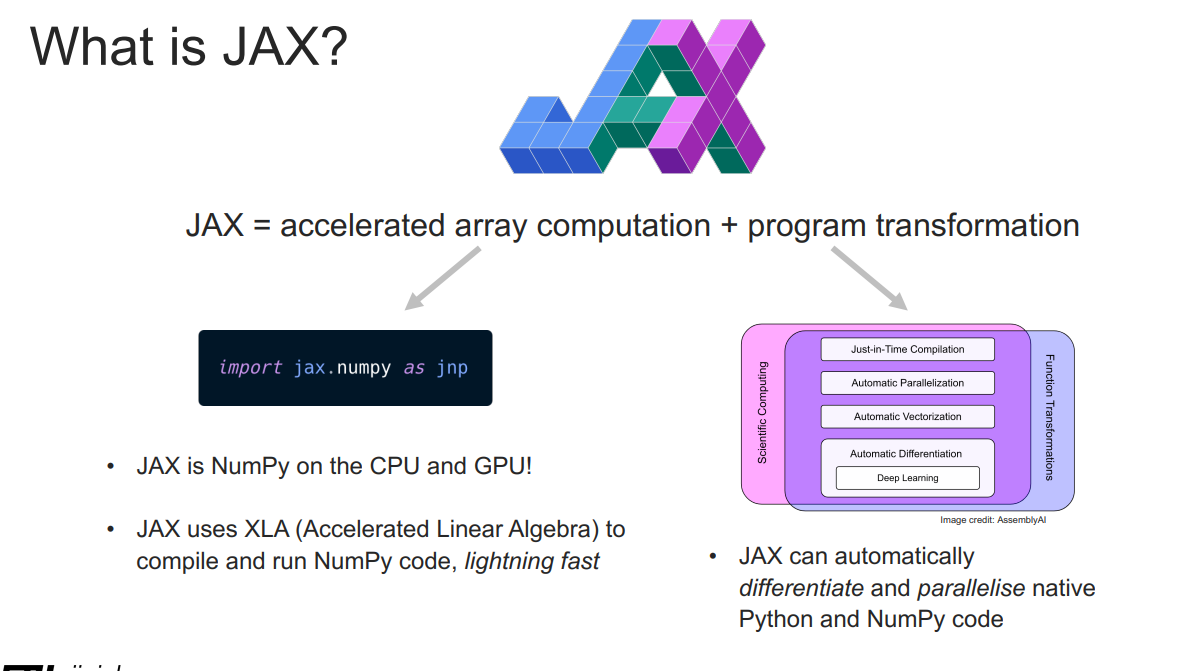

## Tại sao lại chọn JAX?

JAX ngày càng trở nên phổ biến trong các nghiên cứu Học máy Khoa học (Scientific ML / SciML) nhờ vào các tính năng cốt lõi sau:

* **`jit` (Just-In-Time Compilation):** Biên dịch bất kỳ hàm Python/NumPy nào ngay khi chạy $\rightarrow$ mang lại hiệu năng tối ưu gần tương đương với ngôn ngữ C.
* **`grad` (Functional Autodiff):** Tự động tính đạo hàm cho các hàm Python bất kỳ, không bị giới hạn riêng trong cấu trúc `nn.Module` (như PyTorch).
* **`vmap` (Vectorization):** Vectơ hóa một hàm số qua một trục dữ liệu (batch axis) một cách tự động mà không cần phải viết lại mã nguồn của hàm đó.
* **`pmap` (Parallelization):** Song song hóa việc tính toán trên nhiều thiết bị phần cứng (tập hợp các chip TPU/GPU) một cách cực kỳ đơn giản.


### Hướng dẫn cài đặt cấu hình môi trường JAX (Environment Setup)

Google Colab thường đã tích hợp sẵn JAX cho CPU. Tuy nhiên, để đảm bảo bạn có phiên bản mới nhất và hỗ trợ tăng tốc phần cứng (GPU/TPU) tối ưu, hãy chạy lệnh cài đặt sau trong ô Code:


In [ ]:
# CPU-only (simplest for tutorial)
!pip install jax jaxlib

# GPU (CUDA 12)
!pip install -U "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

# Neural network libraries
!pip install flax optax

# 🚀 Tổng quan về các phép biến đổi cốt lõi trong JAX

Notebook này sẽ hướng dẫn bạn từng bước làm chủ các **phép biến đổi nền tảng (core transformations)** của JAX, đi từ lý thuyết cơ bản đến ứng dụng thực tế:

---

### 📌 Nội dung bài học

1. ⚖️ **Mảng JAX (`jnp.array`) vs NumPy (`np.array`)**
   * Sự tương đồng về cú pháp nhưng khác biệt về tính chất (Tính bất biến - Immutability) và nơi lưu trữ dữ liệu (CPU vs GPU Accelerator).

2. ⚡ **`jax.jit` — Trình biên dịch JIT (Just-In-Time)**
   * Cách JAX sử dụng trình biên dịch XLA để gộp các nhân tính toán (Kernel Fusion) và tăng tốc độ thực thi lên mức tối đa (Near-C performance).

3. 📐 **`jax.grad` — Đạo hàm tự động (Automatic Differentiation)**
   * Tiếp cận tư duy toán học thuần túy (Functional Autodiff) để tính đạo hàm bậc cao một cách dễ dàng và chính xác tuyệt đối.

4. 🔄 **`jax.value_and_grad` — Tối ưu hóa tính toán đồng thời**
   * Phép biến đổi "2 trong 1" giúp lấy ra cả giá trị của hàm số (Loss) và đạo hàm (Gradient) trong một lượt chạy duy nhất (One Pass), tiết kiệm tối đa tài nguyên bộ nhớ khi huấn luyện.

5. 🧩 **`jax.vmap` — Tự động vectơ hóa (Vectorization)**
   * Kỹ thuật song song hóa dữ liệu trên GPU mà không cần phải viết lại cấu trúc thuật toán của một phần tử đơn lẻ.

---

### 🛠️ Ứng dụng tổng hợp (Putting it together)
* **Vectorized Gradient Descent:** Kết hợp trọn bộ sức mạnh của `jit`, `value_and_grad`, và `vmap` để xây dựng một mô hình huấn luyện (như Hồi quy tuyến tính hoặc Mạng nơ-ron đa tầng với Flax) chạy song song siêu tốc trên toàn bộ tập dữ liệu.

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print(f'JAX version: {jax.__version__}')
print(f'Devices: {jax.devices()}')

JAX version: 0.7.2
Devices: [CpuDevice(id=0)]


## 🛑 Quy tắc bất di bất dịch: Không thay đổi giá trị tại chỗ (No In-Place Operations)

Một trong những khác biệt cốt lõi nhất về mặt tư duy giữa JAX và các thư viện như PyTorch hay NumPy nằm ở tính chất của bộ nhớ: **Mảng trong JAX là bất biến (Immutable)**. Bạn không thể thay đổi trực tiếp giá trị của một phần tử nằm bên trong mảng sau khi nó đã được khởi tạo.

### ⚖️ So sánh cú pháp: PyTorch vs JAX

*❌ **Trong PyTorch (Hợp lệ):** Thay đổi giá trị tại chỗ (In-place operation) làm biến đổi trực tiếp vùng bộ nhớ cũ.
```python
# PyTorch thay đổi trực tiếp trên mảng x
x[0] = 5.0
# JAX báo lỗi nếu viết x[0] = 5.0
x_new = x.at[0].set(5.0)   # Trả về mảng mới, x gốc giữ nguyên

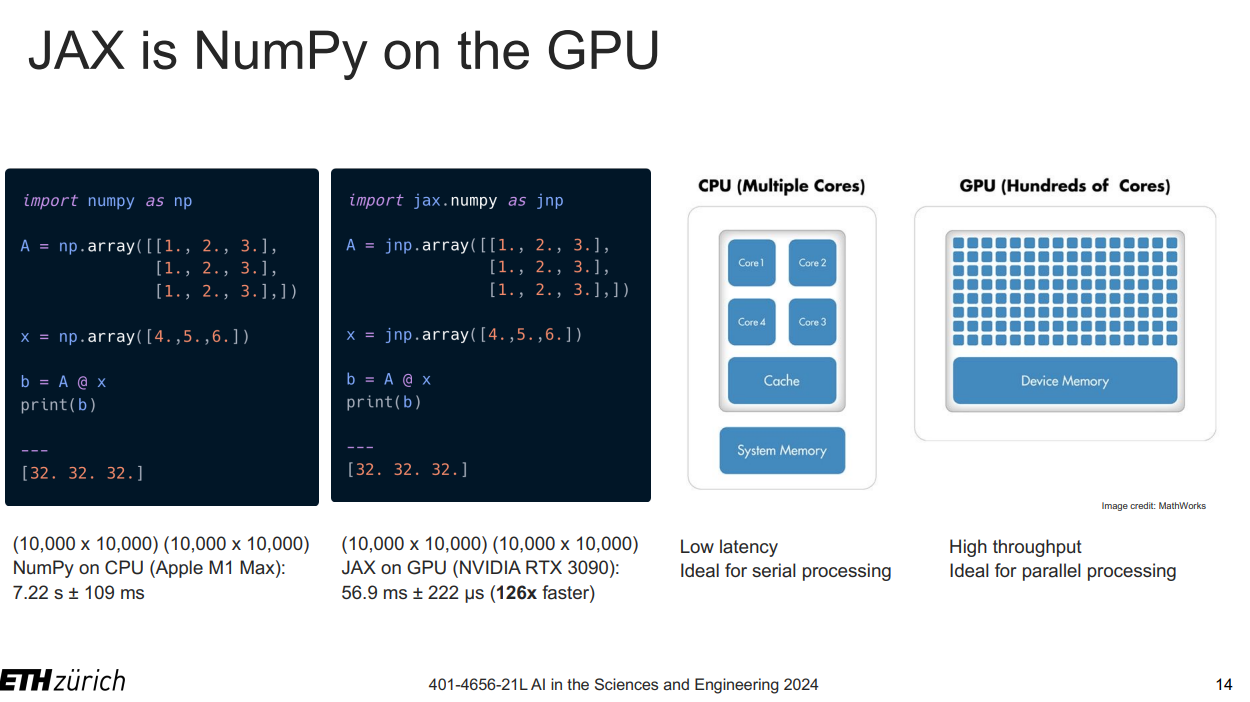

In [ ]:
# JAX arrays look like NumPy but live on the accelerator
x_np = np.array([1.0, 2.0, 3.0])
x_jax = jnp.array([1.0, 2.0, 3.0])

print(f'NumPy type: {type(x_np)}')
print(f'JAX type:   {type(x_jax)}')
print(f'JAX device: {x_jax.device}')

# Most NumPy operations work with jnp
print(jnp.sin(x_jax))
print(jnp.dot(x_jax, x_jax))  # dot product

# IMPORTANT: JAX arrays are immutable — no in-place ops
# x_jax[0] = 5.0  # ERROR!
x_new = x_jax.at[0].set(5.0)  # returns new array
print(f'Original: {x_jax}, Modified copy: {x_new}')

NumPy type: <class 'numpy.ndarray'>
JAX type:   <class 'jaxlib._jax.ArrayImpl'>
JAX device: cuda:0
[0.841471   0.90929747 0.14112   ]
14.0
Original: [1. 2. 3.], Modified copy: [5. 2. 3.]


## ⚡ `jax.jit` — Trình biên dịch JIT (Just-In-Time)

### ⚙️ Nguyên lý hoạt động
* **Lần đầu gọi:** JAX thực hiện **Tracer** (dò hàm bằng giá trị trừu tượng) rồi biên dịch toàn bộ mã sang dạng **XLA HLO Graph** tối ưu.
* **Các lần sau:** Bỏ qua hoàn toàn Python, chạy trực tiếp mã máy tối ưu trên GPU/TPU giúp tăng tốc cực đại.


In [ ]:
def compute_intensive(x):
    for _ in range(100):
        x = jnp.sin(x) + jnp.cos(x)
    return x

x = jnp.ones(10000)

# Without JIT
%timeit compute_intensive(x).block_until_ready()

# With JIT — compiled on first call, fast after
fast_compute = jax.jit(compute_intensive)
fast_compute(x).block_until_ready()  # warm-up / compile
%timeit fast_compute(x).block_until_ready()

25.4 ms ± 6.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
173 µs ± 16.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


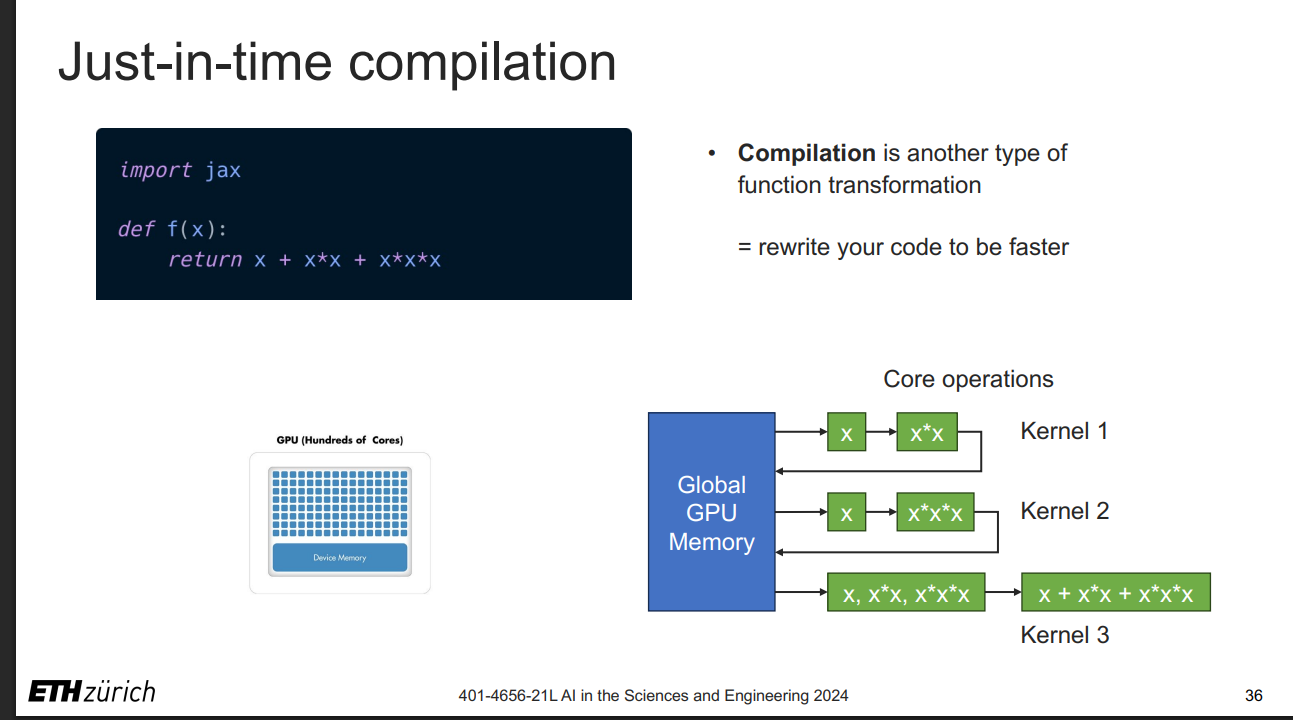

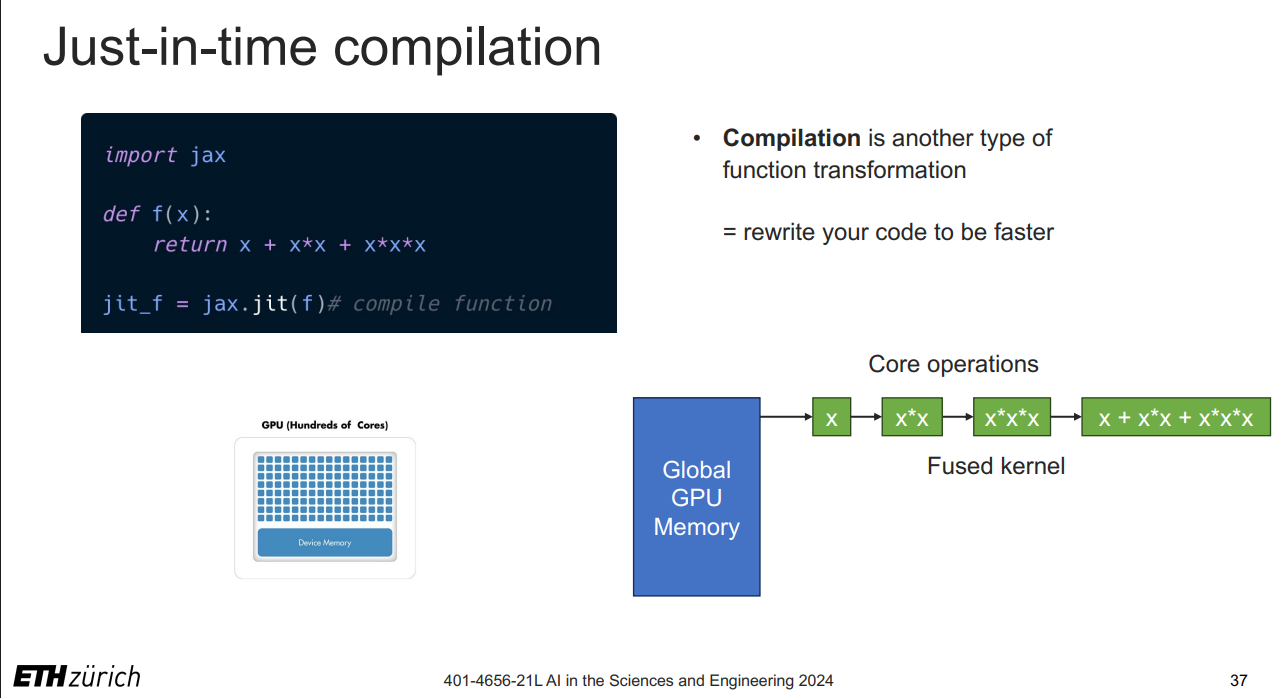

In [ ]:
# 1. Định nghĩa hàm tính RMS thuần túy bằng jax.numpy
def rms(x):
    return jnp.sqrt(jnp.mean(x**2))

# 2. Tạo một vectơ ngẫu nhiên có 1 triệu (1M) phần tử
key = jax.random.PRNGKey(42)
x_1m = jax.random.normal(key, (1000000,))

# 3. Biên dịch JIT cho hàm rms
rms_jit = jax.jit(rms)

# 4. Chạy Warm-up (Làm nóng / Biên dịch lần đầu)
# Bước này ép JAX dịch hàm sang mã máy XLA trước khi đo thời gian
_ = rms_jit(x_1m).block_until_ready()

# 5. So sánh thời gian thực thi bằng %timeit
print("--- ĐANG ĐO THỜI GIAN KHÔNG DÙNG JIT ---")
%timeit rms(x_1m).block_until_ready()

print("\n--- ĐANG ĐO THỜI GIAN CÓ DÙNG JIT ---")
%timeit rms_jit(x_1m).block_until_ready()

--- ĐANG ĐO THỜI GIAN KHÔNG DÙNG JIT ---
The slowest run took 4.12 times longer than the fastest. This could mean that an intermediate result is being cached.
706 µs ± 428 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

--- ĐANG ĐO THỜI GIAN CÓ DÙNG JIT ---
137 µs ± 41.7 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


## 📐 `jax.grad` — Đạo hàm tự động (Automatic Differentiation)

### ⚙️ Điểm khác biệt cốt lõi so với PyTorch
* **PyTorch (Computation Graph):** Xây dựng đồ thị tính toán ngầm khi chạy code. Đạo hàm được tính từ kết quả Loss thông qua lệnh `loss.backward()` và tự động lưu vào thuộc tính `.grad` của từng biến trọng số.
* **JAX (Functional Autodiff):** Xem toàn bộ mô hình như một hàm toán học thuần túy. Phép biến đổi `jax.grad(f)` nhận vào hàm $f$ và trả về một **hàm số mới** đại diện cho đạo hàm của chính hàm đó.



---

### ⚠️ Lưu ý quan trọng
* Hàm đầu vào truyền cho `jax.grad` bắt buộc phải trả về một **giá trị vô hướng (Scalar)**, ví dụ như giá trị của hàm Loss.
* *Giải pháp nếu muốn tính đạo hàm cho hàm trả về vectơ/ma trận:* Sử dụng `jax.jacobian`, `jax.vjp` (Vector-Jacobian Product) hoặc `jax.jvp` (Jacobian-Vector Product).

In [ ]:
# Simple scalar function
f = lambda x: x ** 3 + 2 * x ** 2 - x + 1

df = jax.grad(f)
d2f = jax.grad(df)   # second derivative
# d2f = jax.grad(jax.grad(f))

x_val = 2.0
print(f'f(2)   = {f(x_val)}')
print(f"f'(2)  = {df(x_val)}")   # 3x^2 + 4x - 1 = 12 + 8 - 1 = 19
print(f"f''(2) = {d2f(x_val)}")  # 6x + 4 = 16

f(2)   = 15.0
f'(2)  = 19.0
f''(2) = 16.0


In [ ]:
# Gradient of a vector-input scalar function
def quadratic(w):
    """w^T A w where A = diag([1, 2, 3])."""
    A = jnp.diag(jnp.array([1.0, 2.0, 3.0]))
    return w @ A @ w

grad_fn = jax.grad(quadratic)
w = jnp.array([1.0, 1.0, 1.0])
print(f'Gradient: {grad_fn(w)}')  # should be 2*A*w = [2, 4, 6]

Gradient: [2. 4. 6.]


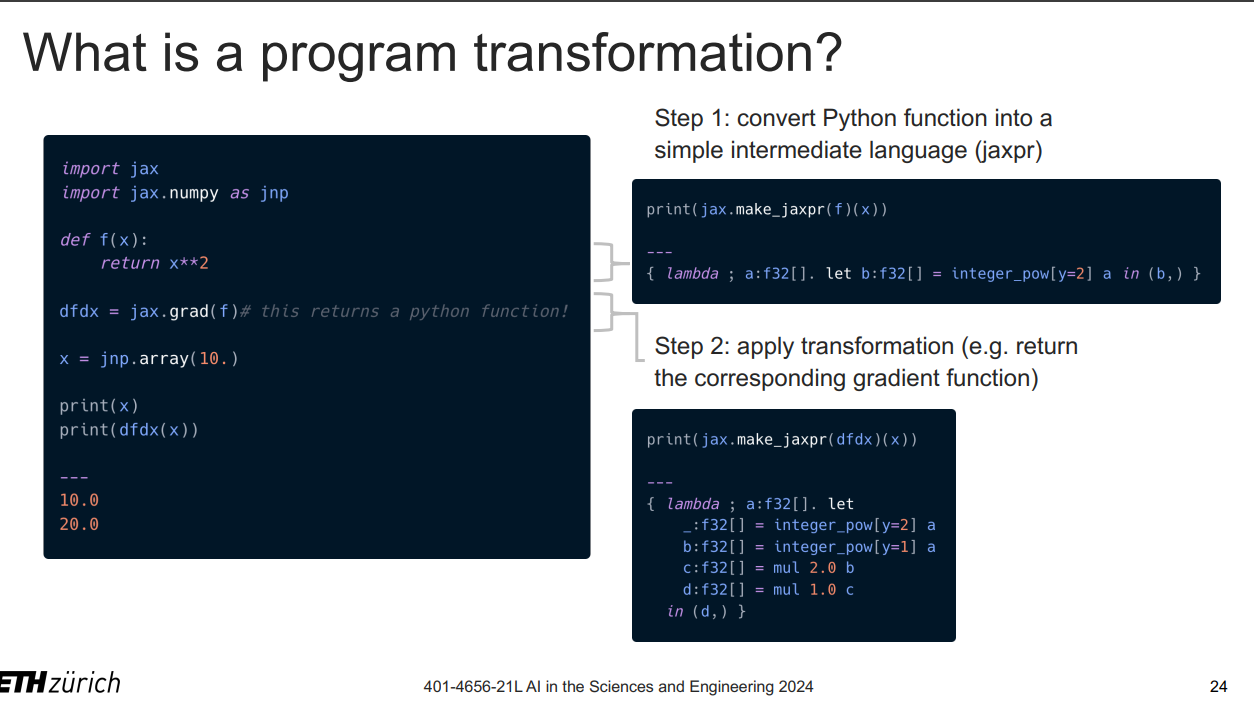

Giá trị x sau 100 bước lặp: 3.0000
Giá trị f(x) nhỏ nhất đạt được: 1.0000


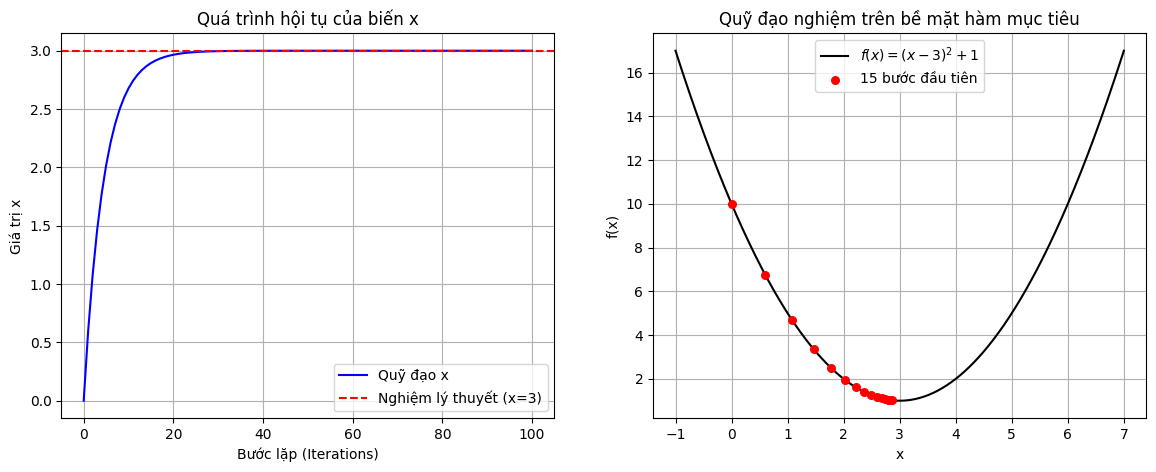

In [ ]:
# 1. Định nghĩa hàm số f(x)
def f(x):
    return (x - 3) ** 2 + 1

# 2. Tính đạo hàm df = jax.grad(f)
df = jax.grad(f)

# --- Cấu hình thuật toán Gradient Descent ---
x = jnp.array(0.0)      # Khởi tạo giá trị x ban đầu tại vị trí x = 0.0
lr = 0.1                # Tốc độ học (Learning rate)
steps = 100             # Số bước lặp cố định là 100 bước

# Mảng lưu lịch sử giá trị của x và loss để vẽ đồ thị
x_history = [float(x)]
loss_history = [float(f(x))]

# 3. Vòng lặp cập nhật: x = x - lr * df(x)
# Sử dụng @jax.jit cho một bước cập nhật để tăng tốc độ thực thi
@jax.jit
def train_step(current_x):
    grads = df(current_x)
    next_x = current_x - lr * grads
    return next_x

for step in range(steps):
    x = train_step(x)

    # Lưu lại lịch sử phục vụ vẽ đồ thị
    x_history.append(float(x))
    loss_history.append(float(f(x)))

print(f"Giá trị x sau {steps} bước lặp: {x:.4f}")
print(f"Giá trị f(x) nhỏ nhất đạt được: {f(x):.4f}")

# 4. Vẽ đồ thị quá trình hội tụ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Sự thay đổi của x qua các bước lặp
ax1.plot(x_history, 'b-', label='Quỹ đạo x')
ax1.axhline(y=3.0, color='r', linestyle='--', label='Nghiệm lý thuyết (x=3)')
ax1.set_xlabel('Bước lặp (Iterations)')
ax1.set_ylabel('Giá trị x')
ax1.set_title('Quá trình hội tụ của biến x')
ax1.legend()
ax1.grid(True)

# Đồ thị 2: Đồ thị hàm số f(x) và các điểm di chuyển của thuật toán
x_vals = jnp.linspace(-1, 7, 500)
ax2.plot(x_vals, f(x_vals), 'k-', label='$f(x) = (x-3)^2 + 1$')
ax2.scatter(x_history[:15], loss_history[:15], color='red', s=30, zorder=3, label='15 bước đầu tiên')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Quỹ đạo nghiệm trên bề mặt hàm mục tiêu')
ax2.legend()
ax2.grid(True)

plt.show()

## 🧩 `jax.vmap` — Tự động vectơ hóa (Vectorization)

### ⚙️ Ý nghĩa đặc biệt trong Lập trình tính toán khoa học (Scientific ML)
Trong mô phỏng vật lý và mô hình hóa (như giải phương trình vi phân hay tính toán phần tử hữu hạn), bạn chỉ cần **viết logic cho một điểm đơn lẻ (single collocation point)** để giữ code cực kỳ sạch sẽ, dễ hiểu. Sau đó, dùng `vmap` để ép hàm đó xử lý tự động cho hàng triệu điểm cùng lúc.

---

### 🌟 3 Ưu điểm vượt trội

1. **Giữ code thuần túy (Clean & Readable):** Bạn chỉ cần tư duy thuật toán cho một mẫu dữ liệu đơn giản, không cần bận tâm đến số chiều của Batch.
2. **Nói không với mẹo biến đổi mảng:** Hoàn toàn loại bỏ các thao tác phức tạp, dễ sai sót như `jnp.reshape`, `jnp.expand_dims`, hoặc các thủ thuật ép chiều (broadcasting tricks).
3. **Tốc độ tối đa (Fast):** JAX không dùng vòng lặp `for` của Python. Trình biên dịch XLA bên dưới sẽ tự động chuyển đổi mã nguồn thành một phép toán ma trận song song khối lượng lớn, chạy trực tiếp trên các lõi của GPU/TPU.

In [ ]:
# Function for a single input (no batch dimension)
def single_prediction(w, x_i):
    """Linear model for ONE sample."""
    return jnp.dot(w, x_i)

w = jnp.array([1.0, 2.0, 3.0])
X = jnp.ones((100, 3))  # batch of 100 samples

# Apply to each sample in X (in_axes=(None, 0) = w is broadcast, X is batched)
batch_predict = jax.vmap(single_prediction, in_axes=(None, 0))
preds = batch_predict(w, X)
print(f'Predictions shape: {preds.shape}')  # (100,)

Predictions shape: (100,)


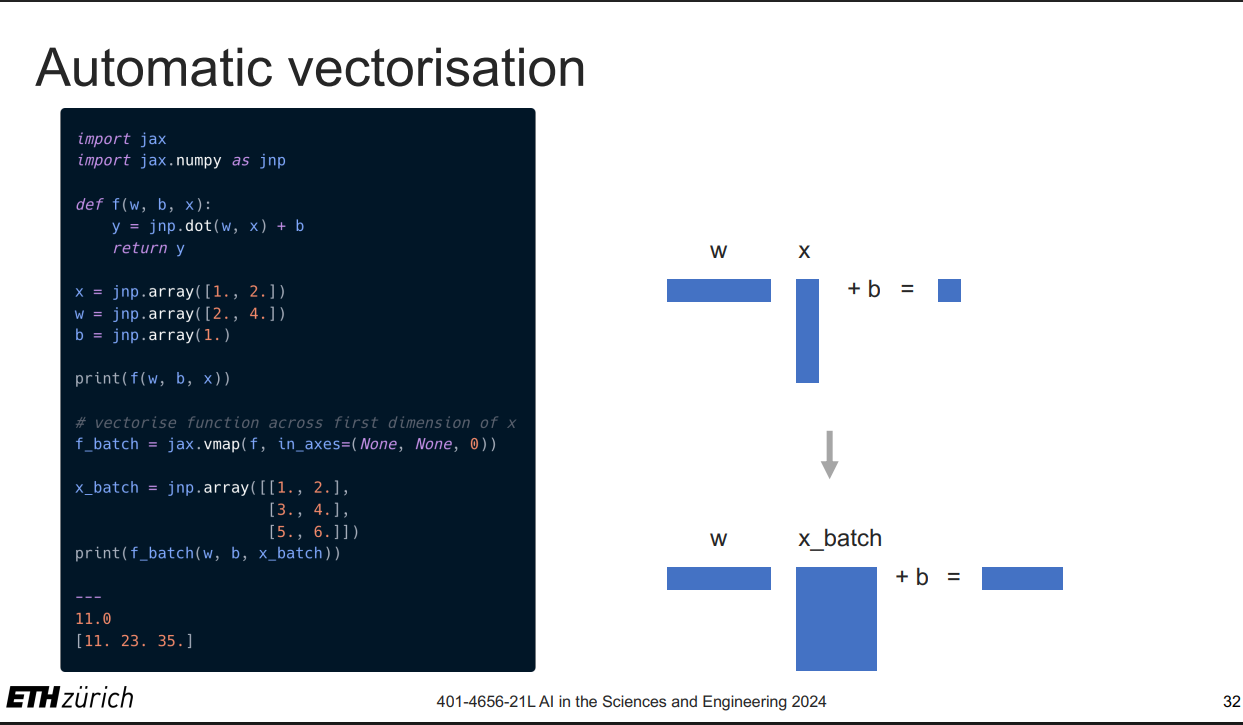

In [ ]:
# vmap + grad: compute per-sample gradients
def per_sample_loss(w, x_i, y_i):
    pred = jnp.dot(w, x_i)
    return (pred - y_i) ** 2

# Gradient w.r.t. w for a SINGLE sample
grad_single = jax.grad(per_sample_loss, argnums=0)

# Vectorize over samples
y = jnp.ones(100)
per_sample_grads = jax.vmap(grad_single, in_axes=(None, 0, 0))(w, X, y)
print(f'Per-sample gradient shape: {per_sample_grads.shape}')  # (100, 3)

Per-sample gradient shape: (100, 3)


In [ ]:
# 1. Định nghĩa hàm f(k, x) = sin(k * x)
def f(k, x):
    return jnp.sin(k * x)

# 2. Tính df/dx cho một cặp (k, x) đơn lẻ
# Vì ta cần đạo hàm theo x, nên chỉ định argnums=1 (đối số thứ hai của hàm f)
df_dx_single = jax.grad(f, argnums=1)

# 3. Sử dụng vmap để tính toán song song cho một mảng các giá trị k
# Đầu vào: mảng k chạy từ 1 đến 5, x là một giá trị vô hướng cố định (x = 1.0)
# Cấu hình in_axes: (0, None) -> Cắt lát mảng k theo trục số 0, giữ nguyên biến x
df_dx_batched = jax.vmap(df_dx_single, in_axes=(0, None))

# Khởi tạo dữ liệu thực tế
k_vals = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0])
x_val = 1.0

# Tính đạo hàm bằng JAX (thực thi trên tập hợp k)
jax_gradients = df_dx_batched(k_vals, x_val)

# 4. Tính toán bằng công thức giải tích (Analytic): d/dx sin(kx) = k * cos(kx)
analytic_gradients = k_vals * jnp.cos(k_vals * x_val)

# --- Hiển thị kết quả so sánh ---
print(f"Hệ số k tương ứng:    {k_vals}")
print("-" * 50)
print(f"Đạo hàm tính bằng JAX: {jax_gradients}")
print(f"Đạo hàm giải tích:    {analytic_gradients}")

# Kiểm tra sai số tuyệt đối tối đa giữa 2 phương pháp
mae = jnp.max(jnp.abs(jax_gradients - analytic_gradients))
print("-" * 50)
print(f"Sai số tuyệt đối lớn nhất: {mae:.2e}")

Hệ số k tương ứng:    [1. 2. 3. 4. 5.]
--------------------------------------------------
Đạo hàm tính bằng JAX: [ 0.5403023 -0.8322936 -2.9699774 -2.6145747  1.4183109]
Đạo hàm giải tích:    [ 0.5403023 -0.8322936 -2.9699774 -2.6145747  1.4183109]
--------------------------------------------------
Sai số tuyệt đối lớn nhất: 0.00e+00


## 🔄 `jax.value_and_grad` — Tối ưu hóa tính toán đồng thời

### ⚙️ Tại sao nên sử dụng?
Thông thường khi huấn luyện mô hình, bạn vừa cần giá trị **Loss** (để in ra màn hình/vẽ đồ thị), vừa cần **Gradient** (để cập nhật trọng số). Thay vì gọi hàm tính Loss riêng rồi gọi `jax.grad` riêng — khiến hệ thống phải chạy lan truyền xuôi (Forward pass) hai lần rất lãng phí tài nguyên — hãy luôn ưu tiên sử dụng `jax.value_and_grad`.

---

### 🌟 Ưu điểm cốt lõi

1. **Hiệu năng vượt trội (Efficient Pass):** JAX chạy Forward và Backward pass một cách thông minh. Nó giữ lại giá trị Loss thu được từ Forward pass và trả về cùng lúc với Gradient, tiết kiệm gần như một nửa thời gian tính toán Forward.
2. **Cấu trúc đầu ra tiện lợi:** Hàm trả về một bộ đôi (tuple) gồm `(loss_value, gradients)`. Trọng số đầu vào (`params`) có cấu trúc cây (PyTree) như thế nào thì `gradients` trả về sẽ có cấu trúc giống hệt như thế, giúp việc cập nhật cực kỳ tường minh.

In [ ]:
def mse_loss(w, X, y):
    preds = X @ w
    return jnp.mean((preds - y) ** 2)

# Efficient: compute loss AND gradient in one pass
loss_and_grad = jax.value_and_grad(mse_loss)

w = jnp.zeros(3)
X = jax.random.normal(jax.random.PRNGKey(0), (50, 3))
y = jax.random.normal(jax.random.PRNGKey(1), (50,))

loss_val, grads = loss_and_grad(w, X, y)
print(f'Loss: {loss_val:.4f}')
print(f'Gradient shape: {grads.shape}')

Loss: 1.1394
Gradient shape: (3,)


## 🌳 Khái niệm về PyTrees trong JAX

Trong JAX, **PyTree** là một thuật ngữ dùng để chỉ các cấu trúc dữ liệu Python được lồng vào nhau một cách có hệ thống. Cụ thể, một PyTree có thể là một `dict` chứa các `list`, một `list` chứa các `tuple`, hoặc bất kỳ sự kết hợp lồng nhau nào của các container này.

* **Nút lá (Leaves):** Các phần tử nằm ở tầng sâu nhất không thể chia nhỏ hơn được nữa trong cây (thường là các mảng JAX `jnp.array` hoặc các số thực/số nguyên `scalar`).
* **Tính năng tự động duyệt cây:** Các phép biến đổi cốt lõi của JAX như `grad`, `jit`, và `vmap` đều được thiết kế để tự động "leo" qua cấu trúc cây này (traverse) mà không cần bạn phải viết các vòng lặp duyệt phần tử thủ công.

### 🧱 Ví dụ thực tế: Quản lý trọng số của mạng Nơ-ron

Thay vì khai báo các biến rời rạc, bạn có thể gom cụm toàn bộ trọng số (Weights) và độ chệch (Biases) của một mạng MLP nhiều tầng vào trong một cấu trúc `dict` lồng nhau:

```python
# Khai báo các tham số mạng nơ-ron dưới dạng một PyTree (dict)
params = {
    'layer_1': {
        'W': jnp.ones((3, 64)),
        'b': jnp.zeros(64),
    },
    'layer_2': {
        'W': jnp.ones((64, 1)),
        'b': jnp.zeros(1),
    }
}

# 🎯 JAX tự động tính đạo hàm qua toàn bộ cấu trúc dict lồng nhau này
grads = jax.grad(loss_fn)(params, x, y)

# 🔄 Cực kỳ kỳ diệu: 'grads' trả về sẽ có CẤU TRÚC CHÍNH XÁC 100% như 'params'
# Nghĩa là bạn có thể truy cập grads['layer_1']['W'] một cách dễ dàng!

--- BẮT ĐẦU HUẤN LUYỆN ---
Step    0 | Loss: 12.4980 | w: 0.7851 | b: 0.1292
Step  100 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  200 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  300 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  400 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  500 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  600 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  700 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  800 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
Step  900 | Loss: 0.0103 | w: 3.0150 | b: 1.0093
--------------------------------------------------
Kết quả sau huấn luyện: w = 3.0150 (Gốc: 3.0) | b = 1.0093 (Gốc: 1.0)


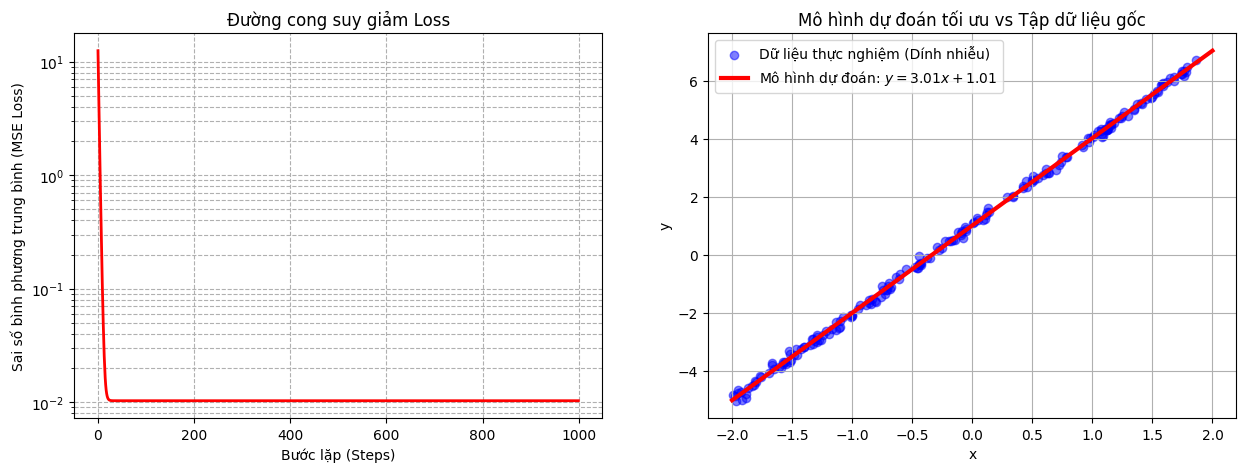

In [ ]:
# =====================================================================
# 1. SINH DỮ LIỆU THỰC NGHIỆM
# =====================================================================
key = jax.random.PRNGKey(42)
key, subkey1, subkey2 = jax.random.split(key, 3)

N = 200
# Tạo dữ liệu X nằm trong khoảng [-2, 2]
X_train = jax.random.uniform(subkey1, (N, 1)) * 4 - 2
# Hàm thực tế: y = 3x + 1 (có cộng thêm nhiễu Gaussian trắng)
y_train = 3 * X_train[:, 0] + 1 + 0.1 * jax.random.normal(subkey2, (N,))

# =====================================================================
# 2. ĐỊNH NGHĨA MÔ HÌNH VÀ HÀM LOSS (MSE)
# =====================================================================
# Khởi tạo tham số ban đầu: w và b gom chung vào một cấu hình (tuple hoặc dict)
# Ở đây ta dùng tuple (w, b) để JAX dễ dàng lấy đạo hàm theo cả hai
params = (jnp.array(0.0), jnp.array(0.0))  # Khởi tạo w=0.0, b=0.0

def mse_loss(params, X, y):
    w, b = params
    preds = w * X[:, 0] + b
    return jnp.mean((preds - y) ** 2)

# =====================================================================
# 3. XÂY DỰNG BƯỚC HUẤN LUYỆN TỐI ƯU VỚI JIT
# =====================================================================
loss_and_grad_fn = jax.value_and_grad(mse_loss)
lr = 0.1

@jax.jit
def train_step(current_params, X, y):
    # Tính đồng thời giá trị Loss và Gradients của w, b
    loss_val, grads = loss_and_grad_fn(current_params, X, y)

    # grads sẽ có cấu trúc tương tự params: (grad_w, grad_b)
    grad_w, grad_b = grads
    w, b = current_params

    # Cập nhật tham số theo thuật toán GD
    new_w = w - lr * grad_w
    new_b = b - lr * grad_b

    return (new_w, new_b), loss_val

# =====================================================================
# 4. VÒNG LẶP HUẤN LUYỆN (1000 STEPS)
# =====================================================================
steps = 1000
loss_history = []

print("--- BẮT ĐẦU HUẤN LUYỆN ---")
for step in range(steps):
    params, loss_val = train_step(params, X_train, y_train)
    loss_history.append(float(loss_val))

    if step % 100 == 0:
        print(f"Step {step:4d} | Loss: {loss_val:.4f} | w: {params[0]:.4f} | b: {params[1]:.4f}")

final_w, final_b = params
print("-" * 50)
print(f"Kết quả sau huấn luyện: w = {final_w:.4f} (Gốc: 3.0) | b = {final_b:.4f} (Gốc: 1.0)")

# =====================================================================
# 5. VẼ ĐỒ THỊ TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Đường cong Loss giảm dần theo thời gian
ax1.plot(loss_history, 'r-', linewidth=2)
ax1.set_yscale('log')  # Dùng thang đo Log để thấy rõ độ mịn khi loss tiệm cận 0
ax1.set_xlabel('Bước lặp (Steps)')
ax1.set_ylabel('Sai số bình phương trung bình (MSE Loss)')
ax1.set_title('Đường cong suy giảm Loss')
ax1.grid(True, which="both", ls="--")

# Đồ thị 2: So sánh đường dự đoán của mô hình với dữ liệu gốc
ax2.scatter(X_train[:, 0], y_train, color='blue', alpha=0.5, label='Dữ liệu thực nghiệm (Dính nhiễu)')
x_plot = jnp.linspace(-2, 2, 100)
y_plot = final_w * x_plot + final_b
ax2.plot(x_plot, y_plot, 'r-', linewidth=3, label=f'Mô hình dự đoán: $y = {final_w:.2f}x + {final_b:.2f}$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Mô hình dự đoán tối ưu vs Tập dữ liệu gốc')
ax2.legend()
ax2.grid(True)

plt.show()